# Latent Autoencoder

Train an autoencoder to learn compressed feature representations of process events.
The latent space can be used for:
- Understanding feature structure
- Clustering similar events
- Visualization (t-SNE/UMAP)
- Anomaly detection

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent
sys.path.insert(0, str(_current))
sys.path.insert(0, str(_current / 'src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from src.interpretability.config.bpic17_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.interpretability.latent_autoencoder import (
    LatentAutoencoder, AutoencoderTrainer, prepare_dataloader
)

%matplotlib inline

In [2]:
# Load model (to get data categories) and dataset
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

print(f"Dataset size: {len(test_dataset)}")
print(f"\nCategorical features ({len(model.data_set_categories[0])}):")
for name, size, _ in model.data_set_categories[0]:
    print(f"  {name}: {size} classes")
print(f"\nNumerical features ({len(model.data_set_categories[1])}):")
for name, _, _ in model.data_set_categories[1]:
    print(f"  {name}")

Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('Action', 7, {'Created': 1, 'Deleted': 2, 'EOS': 3, 'Obtained': 4, 'Released': 5, 'statechange': 6}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'User_109': 13, 'User_11': 14, 'User_110': 15, 'U

## Prepare Data

In [3]:
# Prepare dataloaders
# Split into train/val (80/20)
n_samples = len(test_dataset)
n_train = int(0.8 * n_samples)

indices = torch.randperm(n_samples)
train_indices = indices[:n_train]
val_indices = indices[n_train:]

train_subset = [test_dataset[i] for i in train_indices]
val_subset = [test_dataset[i] for i in val_indices]

print(f"Preparing train loader ({len(train_subset)} samples)...")
train_loader = prepare_dataloader(train_subset, batch_size=256, shuffle=True)
print(f"Preparing val loader ({len(val_subset)} samples)...")
val_loader = prepare_dataloader(val_subset, batch_size=256, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

# Check a batch
batch = next(iter(train_loader))
print(f"\nBatch structure: {len(batch)} tensors")
for i, t in enumerate(batch):
    print(f"  Tensor {i}: shape={t.shape}, dtype={t.dtype}")

Preparing train loader (202556 samples)...
Preparing val loader (50640 samples)...

Train batches: 22211
Val batches: 5531

Batch structure: 10 tensors
  Tensor 0: shape=torch.Size([256]), dtype=torch.int64
  Tensor 1: shape=torch.Size([256]), dtype=torch.int64
  Tensor 2: shape=torch.Size([256]), dtype=torch.int64
  Tensor 3: shape=torch.Size([256]), dtype=torch.int64
  Tensor 4: shape=torch.Size([256]), dtype=torch.int64
  Tensor 5: shape=torch.Size([256]), dtype=torch.int64
  Tensor 6: shape=torch.Size([256]), dtype=torch.int64
  Tensor 7: shape=torch.Size([256]), dtype=torch.int64
  Tensor 8: shape=torch.Size([256]), dtype=torch.int64
  Tensor 9: shape=torch.Size([256, 9]), dtype=torch.float32


## Create and Train Autoencoder

In [4]:
# Configuration
LATENT_DIM = 32  # Larger for BPIC17 (more features)
HIDDEN_DIMS = [128, 64]
EPOCHS = 100
LEARNING_RATE = 1e-3

# Create autoencoder from model categories
autoencoder = LatentAutoencoder.from_model_categories(
    model.data_set_categories,
    latent_dim=LATENT_DIM,
    hidden_dims=HIDDEN_DIMS,
    dropout=0.1
)

print(f"Autoencoder config:")
print(f"  Latent dim: {autoencoder.config.latent_dim}")
print(f"  Hidden dims: {autoencoder.config.hidden_dims}")
print(f"  Num categorical features: {len(autoencoder.config.cat_vocab_sizes)}")
print(f"  Num numerical features: {autoencoder.config.num_features}")

# Count parameters
n_params = sum(p.numel() for p in autoencoder.parameters())
print(f"\nTotal parameters: {n_params:,}")

Autoencoder config:
  Latent dim: 32
  Hidden dims: [128, 64]
  Num categorical features: 9
  Num numerical features: 9

Total parameters: 64,836


In [5]:
# Train
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Training on: {device}")

trainer = AutoencoderTrainer(autoencoder, learning_rate=LEARNING_RATE, device=device)
history = trainer.train(
    train_loader,
    val_loader,
    epochs=EPOCHS,
    early_stopping_patience=15,
    verbose=True
)

Training on: cpu


Training:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping at epoch 20


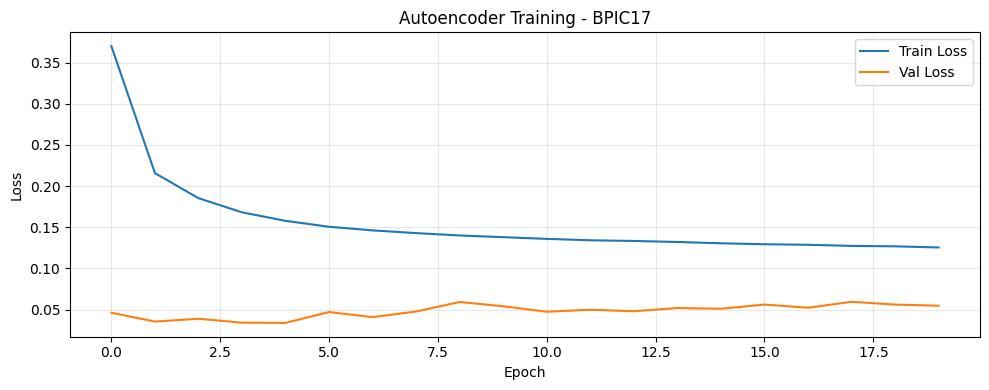

Final train loss: 0.1255
Best val loss: 0.0339


In [6]:
# Plot training history
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], label='Train Loss')
if history['val_loss']:
    ax.plot(history['val_loss'], label='Val Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Autoencoder Training - BPIC17')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train loss: {history['train_loss'][-1]:.4f}")
if history['val_loss']:
    print(f"Best val loss: {min(history['val_loss']):.4f}")

## Extract Latent Representations

In [7]:
# Extract latent representations for all data
print("Preparing full dataloader...")
full_loader = prepare_dataloader(test_dataset, batch_size=512, shuffle=False)

autoencoder.eval()
all_latents = []
all_activities = []  # First categorical feature (concept:name)

print("Extracting latent representations...")
with torch.no_grad():
    for batch in full_loader:
        cat_inputs = [t.to(device) for t in batch[:-1]]
        num_inputs = batch[-1].to(device)
        
        latent = autoencoder.encode(cat_inputs, num_inputs)
        all_latents.append(latent.cpu())
        all_activities.append(cat_inputs[0].cpu())  # Activity is first categorical

latents = torch.cat(all_latents, dim=0).numpy()
activities = torch.cat(all_activities, dim=0).numpy()

print(f"Latent representations shape: {latents.shape}")
print(f"Activities shape: {activities.shape}")

Preparing full dataloader...
Extracting latent representations...
Latent representations shape: (7101740, 32)
Activities shape: (7101740,)


## Visualize Latent Space (t-SNE)

In [8]:
# Get activity names
activity_mapping = {v: k for k, v in model.data_set_categories[0][0][2].items()}

# Subsample for t-SNE (faster)
n_vis = min(5000, len(latents))
vis_indices = np.random.choice(len(latents), n_vis, replace=False)
latents_vis = latents[vis_indices]
activities_vis = activities[vis_indices]

print(f"Running t-SNE on {n_vis} samples...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
latents_2d = tsne.fit_transform(latents_vis)
print("Done!")

Running t-SNE on 5000 samples...


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

In [ ]:
# Plot t-SNE colored by activity
fig, ax = plt.subplots(figsize=(14, 10))

# Get unique activities (excluding padding=0)
unique_activities = sorted(set(activities_vis) - {0})
colors = plt.cm.tab20(np.linspace(0, 1, min(20, len(unique_activities))))

# Only show top activities by count for cleaner legend
activity_counts = {act: (activities_vis == act).sum() for act in unique_activities}
top_activities = sorted(activity_counts.keys(), key=lambda x: -activity_counts[x])[:15]

for i, act_idx in enumerate(top_activities):
    mask = activities_vis == act_idx
    act_name = activity_mapping.get(act_idx, f'Unknown_{act_idx}')
    if 'EOS' in act_name:
        continue
    ax.scatter(
        latents_2d[mask, 0],
        latents_2d[mask, 1],
        c=[colors[i % 20]],
        label=f'{act_name[:25]} ({mask.sum()})',
        alpha=0.6,
        s=15
    )

# Plot remaining activities in gray
other_mask = ~np.isin(activities_vis, top_activities + [0])
if other_mask.sum() > 0:
    ax.scatter(
        latents_2d[other_mask, 0],
        latents_2d[other_mask, 1],
        c='lightgray',
        label=f'Other ({other_mask.sum()})',
        alpha=0.3,
        s=10
    )

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title(f'Latent Space Visualization - BPIC17\n(colored by Activity, latent_dim={LATENT_DIM})')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## Reconstruction Quality

In [ ]:
# Evaluate reconstruction accuracy
autoencoder.eval()
correct_per_feature = {}
total_per_feature = {}

cat_names = [name for name, _, _ in model.data_set_categories[0]]

for name in cat_names:
    correct_per_feature[name] = 0
    total_per_feature[name] = 0

with torch.no_grad():
    for batch in full_loader:
        cat_inputs = [t.to(device) for t in batch[:-1]]
        num_inputs = batch[-1].to(device)
        
        _, cat_logits, _ = autoencoder(cat_inputs, num_inputs)
        
        for i, (name, target, logits) in enumerate(zip(cat_names, cat_inputs, cat_logits)):
            pred = logits.argmax(dim=-1)
            mask = target != 0  # Ignore padding
            correct_per_feature[name] += (pred[mask] == target[mask]).sum().item()
            total_per_feature[name] += mask.sum().item()

print("Reconstruction Accuracy by Feature:")
print("=" * 60)

# Sort by accuracy
accuracies = []
for name in cat_names:
    if total_per_feature[name] > 0:
        acc = correct_per_feature[name] / total_per_feature[name]
        accuracies.append((name, acc, correct_per_feature[name], total_per_feature[name]))

for name, acc, correct, total in sorted(accuracies, key=lambda x: -x[1]):
    bar = '█' * int(acc * 20) + '░' * (20 - int(acc * 20))
    print(f"  {name:30s} {bar} {acc:.1%}")

## Latent Space Statistics

In [ ]:
# Analyze latent space statistics
print("Latent Space Statistics:")
print("=" * 50)
print(f"  Shape: {latents.shape}")
print(f"  Mean: {latents.mean():.4f}")
print(f"  Std:  {latents.std():.4f}")
print(f"  Min:  {latents.min():.4f}")
print(f"  Max:  {latents.max():.4f}")

# Per-dimension statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of all latent values
axes[0].hist(latents.flatten(), bins=50, density=True, alpha=0.7)
axes[0].set_xlabel('Latent Value')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of Latent Values')

# Per-dimension mean and std
dim_means = latents.mean(axis=0)
dim_stds = latents.std(axis=0)
x = np.arange(LATENT_DIM)
axes[1].bar(x, dim_means, yerr=dim_stds, capsize=2, alpha=0.7)
axes[1].set_xlabel('Latent Dimension')
axes[1].set_ylabel('Mean (+/- Std)')
axes[1].set_title('Per-Dimension Statistics')
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Save model
save_path = _current / 'src' / 'interpretability' / 'notebooks' / 'bpic17' / 'autoencoder_model.pt'
torch.save({
    'config': autoencoder.config,
    'state_dict': autoencoder.state_dict(),
    'history': history
}, save_path)
print(f"Model saved to: {save_path}")